# Notebook Finance AI - Asistente Inteligente de Salud Financiera

## Librerias necesarias

In [1]:
import pandas as pd
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
# import requests
# import json
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE

Obtención de datos 

## Proceso ETL

### Extraer

In [2]:
# url = 'https://raw.githubusercontent.com/No-Country-simulation/G9-LATAM-Team71/refs/heads/develop/data-science/csv_prueba_modelo.csv' 
url = 'csv_prueba_modelo.csv'
data = pd.read_csv(url, encoding='utf-8')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18179 entries, 0 to 18178
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   descripcion  18179 non-null  str    
 1   categoria    18179 non-null  str    
 2   tipo         18179 non-null  str    
 3   cualidad     18179 non-null  str    
 4   monto        18179 non-null  float64
 5   fecha        18179 non-null  str    
dtypes: float64(1), str(5)
memory usage: 852.3 KB


In [3]:
data.sample(5)

,descripcion,categoria,tipo,cualidad,monto,fecha
16347,Didi a casa,TRANSPORTE,EGRESO,VARIABLE,247.92,2/2/2026
1608,Bono por desempeño,INGRESO,INGRESO,VARIABLE,2363.06,1/11/2026
3576,Bono por desempeño,INGRESO,INGRESO,VARIABLE,6468.62,3/2/2026
14522,Proyecto freelance desarrollo,INGRESO,INGRESO,VARIABLE,6053.03,11/23/2026
2637,Venta de bicicleta,INGRESO,INGRESO,VARIABLE,6107.25,2/7/2026


### Transformar

In [4]:
# limpiar datos
for i in range(1,4):
    data.iloc[:,i] = data.iloc[:,i].str.replace(r'[^\w\s]', '',regex = True).str.upper().str.strip()
    # data.iloc[:,i] = data.iloc[:,i].

# pasar a tipo de dato fecha
data.fecha = data.fecha.str.replace('-','/').str.strip()
data.fecha = pd.to_datetime(data.fecha, errors='coerce')

In [165]:
data.head(
    
)

,descripcion,categoria,tipo,cualidad,monto,fecha
0,compra refresco oxxo,ALIMENTACION,EGRESO,VARIABLE,50.00,2026-07-20
1,despensa bodega aurrera,ALIMENTACION,EGRESO,FIJO_VITAL,1365.16,2026-04-01
2,refresco en tienda,ALIMENTACION,EGRESO,VARIABLE,112.98,2026-04-01
3,didi hacia el trabajo,TRANSPORTE,EGRESO,VARIABLE,92.87,2026-04-01
4,mensualidad gimnasio smartfit,SALUD,EGRESO,FIJO_NO_VITAL,400.00,2026-04-02


In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 18178 entries, 0 to 18178
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   descripcion  18178 non-null  str           
 1   categoria    18178 non-null  str           
 2   tipo         18178 non-null  str           
 3   cualidad     18178 non-null  str           
 4   monto        18178 non-null  float64       
 5   fecha        17725 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 994.1 KB


### Carga

En este caso no se genera un archivo pues este notebook es donde se hace el análisis

## NLP
Proceso para generar el modelo a utilizar

Separacion de variables, la variable a predecir (y) es la categoria que representa la descripción

In [31]:
y_categoria = data.categoria
X_categoria = data.descripcion
X_cualidad = data.descripcion
y_cualidad = data.cualidad

Grupo de palabras que se usan para delimitar la oración, y quedan fuera de nuestra lista

In [32]:
stop_words = [
    "de",
    "del",
    "la",
    "las",
    "el",
    "los",
    "en",
    "con",
    "para",
    "por",
    "y"
]

In [33]:
# funcion para dividir datos
def split_variables(X,y):
    X,X_test,y,y_test = train_test_split(X,y,stratify = y,random_state=5,test_size=0.15)#stratify indica que si hay un 10% de una variable, entonces ese 10 % tambien lo ponga en la division
    X_train,X_val,y_train,y_val = train_test_split(X,y,stratify = y,random_state=5) #x de entrenamiento
    return X,X_test,X_train, X_val,y,y_test, y_train, y_val

X_categoria, X_categoria_test,X_categoria_train, X_categoria_val, y_categoria, y_categoria_test, y_categoria_train,y_categoria_val = split_variables(X_categoria,y_categoria) # datos de entrenamiento para categoria

X_cualidad, X_cualidad_test,X_cualidad_train, X_cualidad_val, y_cualidad, y_cualidad_test, y_cualidad_train, y_cualidad_val = split_variables(X_cualidad,y_cualidad)   #datos de entrenamiento para cualidad


skf = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 5)

In [34]:
# funcion prueba modelo
# metricas
metrics = ['accuracy','recall_macro','f1_macro']


def probar_modelo(X,y, modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',TfidfVectorizer(stop_words=stop_words)),('balanceo',balanceo),('modelo',modelo)])

  cv_resultados = cross_validate(pipeline,X,y,cv=skf,scoring=metrics)
  return cv_resultados


# funcion ejecutar modelo
def entrenar_modelo(modelo, balanceo = None):
  pipeline = imbpipeline([('vectorizacion',TfidfVectorizer(stop_words=stop_words)),('balanceo',balanceo),('modelo',modelo)])

  return pipeline

### Modelos a probar

* Logistic Regression
* Random Forest
* Linear SVC

### Logistic Regression

Es un modelo parecido a *Linear Regression* con la diferencia de que este modelo predice a partir de categorías y no de números como lo hace la regresión lineal

In [35]:
#categoria
mod_categoria_regresion_normal = probar_modelo(X_categoria,y_categoria,LogisticRegression());
mod_categoria_regresion_balanceado = probar_modelo(X_categoria,y_categoria,LogisticRegression(),SMOTE());

#cualidad
mod_cualidad_regresion_normal = probar_modelo(X_cualidad,y_cualidad,LogisticRegression());
mod_cualidad_regresion_balanceado = probar_modelo(X_cualidad,y_cualidad,LogisticRegression(),SMOTE());

pd.DataFrame({
    "Regresion logistica categoria":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion logistica categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion logistica cualidad":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion logistica cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion logistica categoria,0.182223,0.034371,0.982655,0.844347,0.881466
Regresion logistica categoria balanceada,1.437448,0.037962,0.964922,0.896591,0.862529
Regresion logistica cualidad,0.182223,0.034371,0.982655,0.844347,0.881466
Regresion logistica cualidad balanceada,1.437448,0.037962,0.964922,0.896591,0.862529


#### Random Forest

In [36]:


mod_categoria_forest = probar_modelo(X_categoria,y_categoria,RandomForestClassifier(max_depth=5));
mod_categoria_forest_balanceado = probar_modelo(X_categoria,y_categoria,RandomForestClassifier(max_depth=5),SMOTE());

#cualidad
mod_cualidad_forest_normal = probar_modelo(X_cualidad,y_cualidad,RandomForestClassifier(max_depth=5));
mod_cualidad_forest_balanceado = probar_modelo(X_cualidad,y_cualidad,RandomForestClassifier(max_depth=5),SMOTE());


pd.DataFrame({
    "Modelo Forest categoria":pd.DataFrame(mod_categoria_forest).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad":pd.DataFrame(mod_cualidad_forest_normal).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo Forest categoria,0.296569,0.050442,0.828231,0.111111,0.100672
Modelo Forest categoria balanceado,1.469525,0.047605,0.578672,0.755830,0.568709
Modelo Forest cualidad,0.258321,0.045597,0.793414,0.422817,0.426759
Modelo Forest cualidad balanceado,0.583977,0.046803,0.989774,0.975702,0.963677


#### Linear SVC

In [37]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
mod_categoria_LinearSVC_normal = probar_modelo(X_categoria,y_categoria,LinearSVC());
mod_categoria_LinearSVC_balanceado = probar_modelo(X_categoria,y_categoria,LinearSVC(),SMOTE());

#cualidad
mod_cualidad_LinearSVC_normal = probar_modelo(X_cualidad,y_cualidad,LinearSVC());
mod_cualidad_LinearSVC_balanceado = probar_modelo(X_cualidad,y_cualidad,LinearSVC(),SMOTE());

pd.DataFrame({
    "Modelo LinearSVC categoria":pd.DataFrame(mod_categoria_LinearSVC_normal).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad":pd.DataFrame(mod_cualidad_LinearSVC_normal).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Modelo LinearSVC categoria,3.893144,0.036339,0.988092,0.893281,0.906995
Modelo LinearSVC categoria balanceado,17.304503,0.036238,0.965893,0.896065,0.866428
Modelo LinearSVC cualidad,0.988278,0.034550,0.996570,0.984327,0.971717
Modelo LinearSVC cualidad balanceado,2.559377,0.035361,0.996246,0.984224,0.971450


## Comparación de modelos y modelo elegido

In [38]:
pd.DataFrame({
    "Regresion logistica categoria balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Regresion logistica cualidad balanceada":pd.DataFrame(mod_categoria_regresion_balanceado).mean(),
    "Modelo Forest categoria balanceado":pd.DataFrame(mod_categoria_forest_balanceado).mean(),
    "Modelo Forest cualidad balanceado":pd.DataFrame(mod_cualidad_forest_balanceado).mean(),
    "Modelo LinearSVC categoria balanceado":pd.DataFrame(mod_categoria_LinearSVC_balanceado).mean(),
    "Modelo LinearSVC cualidad balanceado":pd.DataFrame(mod_cualidad_LinearSVC_balanceado).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion logistica categoria balanceada,1.437448,0.037962,0.964922,0.896591,0.862529
Regresion logistica cualidad balanceada,1.437448,0.037962,0.964922,0.896591,0.862529
Modelo Forest categoria balanceado,1.469525,0.047605,0.578672,0.755830,0.568709
Modelo Forest cualidad balanceado,0.583977,0.046803,0.989774,0.975702,0.963677
Modelo LinearSVC categoria balanceado,17.304503,0.036238,0.965893,0.896065,0.866428
Modelo LinearSVC cualidad balanceado,2.559377,0.035361,0.996246,0.984224,0.971450


In [39]:
pd.DataFrame({
    "Regresion logistica categoria":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Regresion logistica cualidad":pd.DataFrame(mod_categoria_regresion_normal).mean(),
    "Modelo Forest categoria":pd.DataFrame(mod_categoria_forest).mean(),
    "Modelo Forest cualidad":pd.DataFrame(mod_cualidad_forest_normal).mean(),
    "Modelo LinearSVC categoria":pd.DataFrame(mod_categoria_LinearSVC_normal).mean(),
    "Modelo LinearSVC cualidad":pd.DataFrame(mod_cualidad_LinearSVC_normal).mean()
}).T

,fit_time,score_time,test_accuracy,test_recall_macro,test_f1_macro
Regresion logistica categoria,0.182223,0.034371,0.982655,0.844347,0.881466
Regresion logistica cualidad,0.182223,0.034371,0.982655,0.844347,0.881466
Modelo Forest categoria,0.296569,0.050442,0.828231,0.111111,0.100672
Modelo Forest cualidad,0.258321,0.045597,0.793414,0.422817,0.426759
Modelo LinearSVC categoria,3.893144,0.036339,0.988092,0.893281,0.906995
Modelo LinearSVC cualidad,0.988278,0.034550,0.996570,0.984327,0.971717


El modelo con valores mas altos en *recall*, *accuracy* y *f1* fue el **Linear SVC** normal para **CATEGORIA**, y **CUALIDAD** normal para  por lo que ese será el modelo a tomar y con el que se obtendrán algunas métricas. Otra cosa a tomar en cuenta es que si bien en algunos modelos puede ser un poco mayor el valor de *f1* y *recall*, estos modelos tienen un *fit_score* considerablemrnte mas alto que los elegidos, y a fin de optimizar el proceso se usan estos modelos

### Prueba de modelo 

              precision    recall  f1-score   support

ALIMENTACION       0.94      0.99      0.96       165
      DEUDAS       0.92      1.00      0.96        22
   EDUCACION       0.95      0.89      0.92        44
     INGRESO       1.00      0.95      0.98      2258
        OCIO       0.99      0.88      0.93        81
       SALUD       0.98      0.98      0.98        45
   SERVICIOS       0.16      0.83      0.27        24
  TRANSPORTE       0.99      0.96      0.97        77
    VIVIENDA       0.64      0.82      0.72        11

    accuracy                           0.95      2727
   macro avg       0.84      0.92      0.85      2727
weighted avg       0.98      0.95      0.97      2727



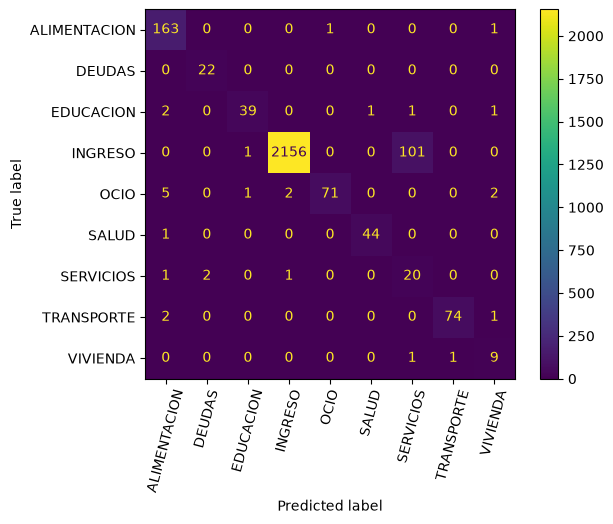

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


modelo_categoria_svm = entrenar_modelo(CalibratedClassifierCV(LinearSVC()),SMOTE())
modelo_categoria_svm.fit(X_categoria_train, y_categoria_train)



y_pred = modelo_categoria_svm.predict(X_categoria_test)
print(classification_report(y_categoria_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_categoria_test,y_pred,xticks_rotation=75);

               precision    recall  f1-score   support

FIJO_NO_VITAL       0.82      1.00      0.90         9
   FIJO_VITAL       0.99      1.00      1.00       758
     VARIABLE       1.00      1.00      1.00      1960

     accuracy                           1.00      2727
    macro avg       0.94      1.00      0.96      2727
 weighted avg       1.00      1.00      1.00      2727



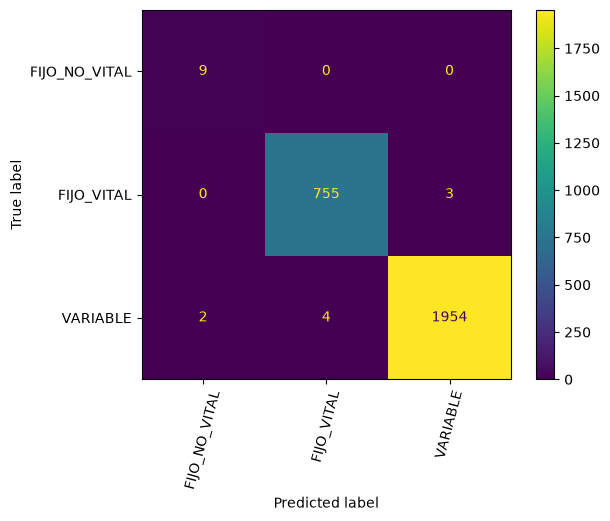

In [45]:
modelo_cualidad_svm = entrenar_modelo(CalibratedClassifierCV(LinearSVC()),SMOTE())
modelo_cualidad_svm.fit(X_cualidad_train,y_cualidad_train)

y_pred = modelo_cualidad_svm.predict(X_cualidad_test)
print(classification_report(y_cualidad_test,y_pred))
ConfusionMatrixDisplay.from_predictions(y_cualidad_test,y_pred,xticks_rotation=75);

#### Serialización de modelos

In [ ]:
import pickle
try:
  with open('models/categoria_champion.pkl','wb') as file:
    pickle.dump(modelo_categoria_svm,file)

  with open('models/cualidad_champion.pkl','wb') as file:
    pickle.dump(modelo_cualidad_svm,file)

except exception as e:
  print('Se presento error al realizar el modelo')

## Análisis financiero

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18179 entries, 0 to 18178
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   descripcion  18179 non-null  str           
 1   categoria    18179 non-null  str           
 2   tipo         18179 non-null  str           
 3   cualidad     18179 non-null  str           
 4   monto        18179 non-null  float64       
 5   fecha        17726 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 852.3 KB


El análisis financiero se evaluaran los siguientes indicadores, intentando cubrir las características mas importantes y útiles para el usuario
* tasa de ahorro
* nivel de endeudamiento
* porcentaje del ingreso gastado
* categoría con mayor gasto
* frecuencia de ahorro
* gasto promedio

Además de mostrar una comparativa al periodo anterior

In [105]:
# Variables usadas
fecha_inicio = pd.Timestamp.today().normalize() - pd.Timedelta(days = 30)
fecha_fin = pd.Timestamp("2026-08-10")
fecha_inicio_analisis = fecha_fin - pd.Timedelta(days = 30)

In [73]:
pd.Timestamp.today().normalize() - pd.Timedelta(days = 50)

Timestamp('2026-07-04 00:00:00')

In [108]:
#periodo seleccionado completo

def seleccionar_periodo(data,fecha_inicio,fecha_fin):
    data = data.copy()

    data["fecha"] = pd.to_datetime(data["fecha"])

    return data[
        (data["fecha"] >= fecha_inicio) &
        (data["fecha"] <= fecha_fin)
    ]

duracion = fecha_fin - fecha_inicio_analisis

fecha_fin_anterior = fecha_inicio - pd.Timedelta(days=1)    #analisis comienza justo antes que hoy
fecha_inicio_anterior = fecha_fin_anterior - duracion

data_anterior = seleccionar_periodo(data,fecha_inicio_analisis,fecha_fin_anterior)

data_actual = seleccionar_periodo(data,fecha_inicio_analisis,fecha_fin)


In [109]:
fecha_fin_anterior

Timestamp('2026-07-23 00:00:00')

In [110]:
fecha_fin

Timestamp('2026-08-10 00:00:00')

#### Tasa de ahorro
Es lo que se tiene respecto a lo que se gastó

In [75]:
data.head()

,descripcion,categoria,tipo,cualidad,monto,fecha
0,compra refresco oxxo,ALIMENTACION,EGRESO,VARIABLE,50.00,2026-07-20
1,despensa bodega aurrera,ALIMENTACION,EGRESO,FIJO_VITAL,1365.16,2026-04-01
2,refresco en tienda,ALIMENTACION,EGRESO,VARIABLE,112.98,2026-04-01
3,didi hacia el trabajo,TRANSPORTE,EGRESO,VARIABLE,92.87,2026-04-01
4,mensualidad gimnasio smartfit,SALUD,EGRESO,FIJO_NO_VITAL,400.00,2026-04-02


In [76]:
# ACTUAL
# ------
ingreso = data_actual[data_actual.tipo == "INGRESO"].monto.sum()
egreso = data_actual[data_actual.tipo =="EGRESO"].monto.sum()
ahorro = ingreso - egreso
# ahorro
tasa_ahorro_actual = ahorro/ingreso*100

# ANTERIOR
# ---------------
ingreso_anterior = data_anterior[data_anterior.tipo == "INGRESO"].monto.sum()
egreso_anterior = data_anterior[data_anterior.tipo =="EGRESO"].monto.sum()
ahorro_anterior = ingreso_anterior - egreso_anterior
# ahorro
tasa_ahorro_anterior = (ahorro_anterior/ingreso_anterior)*100


C:\Users\tavios\AppData\Local\Temp\ipykernel_12144\2403272277.py:15: RuntimeWarning: invalid value encountered in scalar divide
  tasa_ahorro_anterior = (ahorro_anterior/ingreso_anterior)*100


#### Nivel de endeudamiento
mide la proporción de recursos externos o deudas que se usan para financiar activos frente a los ingresos, es decir, cuanto se gasta en deudas, un máximo de 35 a 40%


In [77]:
# ACTUAL
deuda = data_actual[(data_actual.categoria == "DEUDAS") &
             data_actual.tipo == "EGRESO"].monto.sum()
nivel_endeudamiento_actual = (deuda/ingreso)*100

#ANTERIOR
deuda = data_anterior[(data_anterior.categoria == "DEUDAS") &
             data_anterior.tipo == "EGRESO"].monto.sum()
nivel_endeudamiento_anterior = (deuda/ingreso_anterior)*100


C:\Users\tavios\AppData\Local\Temp\ipykernel_12144\486246568.py:2: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  deuda = data_actual[(data_actual.categoria == "DEUDAS") &
C:\Users\tavios\AppData\Local\Temp\ipykernel_12144\486246568.py:7: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  deuda = data_anterior[(data_anterior.categoria == "DEUDAS") &
C:\Users\tavios\AppData\Local\Temp\ipykernel_12144\486246568.py:9: RuntimeWarning: invalid value encountered in scalar divide
  nivel_endeudamiento_anterior = (deuda/ingreso_anterior)*100


#### Porcentaje de ingreso gastado

In [78]:
def calcular_porcentaje_ingreso_gastado(data):

    ingresos = data[
        data["tipo"] == "INGRESO"
    ]["monto"].sum()

    egresos = data[
        data["tipo"] == "EGRESO"
    ]["monto"].sum()

    if ingresos == 0:
        return 0

    return (egresos / ingresos) * 100

# ACTUAL
porcentaje_gastado_actual = calcular_porcentaje_ingreso_gastado(data_actual)

#ANTERIOR
porcentaje_gastado_anterior = calcular_porcentaje_ingreso_gastado(data_anterior)

#### Categoría con mayor gasto
Que categoría ha gastado mas

In [79]:
def categoria_mayor_gasto(data):
    gastos_controlables = data[
        (data["tipo"] == "EGRESO") &
        (data["cualidad"] != "FIJO_VITAL")
    ]
    if gastos_controlables.empty:
        return {
        "categoria_mayor": None,
        "porcentaje_categoria": 0
    }

    gastos_categoria = (
        gastos_controlables
        .groupby("categoria")["monto"]
        .sum()
        .sort_values(ascending=False)
    )

    total_gastos = gastos_categoria.sum()

    categoria = gastos_categoria.index[0]

    porcentaje = (
        gastos_categoria.iloc[0] /
        total_gastos
    ) * 100

    return {
        "categoria_mayor": categoria,
        "porcentaje_categoria": porcentaje
    }

# ACTUAL
categoria_porcentaje_mayor_gasto_actual = categoria_mayor_gasto(data_actual) 

# ANTERIOR
categoria_porcentaje_mayor_gasto_anterior = categoria_mayor_gasto(data_anterior) 

#### Gasto promedio general y controlable (cualidad **variable** y **fijo no vital**)

In [80]:
# gasto controlable
gastos_controlables = data_actual[                 #SEconsidera 
    (data_actual["tipo"] == "EGRESO") &
    (data_actual["cualidad"] != "FIJO_VITAL")]
gasto_promedio_controlable_actual = gastos_controlables.monto.mean()

#gasto promedio
gastos_totales = data[data.tipo == "EGRESO"]
gasto_promedio_actual = gastos_totales.monto.mean()


#### Gasto promedio

In [81]:
## ACTUAL
# gasto_promedio controlable
gastos_controlables = data_actual[                 #SEconsidera 
    (data_actual["tipo"] == "EGRESO") &
    (data_actual["cualidad"] != "FIJO_VITAL")
]
gasto_promedio_controlable_actual = gastos_controlables.monto.mean()

# gasto promedio general
gasto_promedio_actual = data_actual[data_actual.tipo == "EGRESO"].monto.mean()

## ANTERIOR
# gasto_promedio controlable
gastos_controlables = data_anterior[                 #SEconsidera 
    (data_anterior["tipo"] == "EGRESO") &
    (data_anterior["cualidad"] != "FIJO_VITAL")
]
gasto_promedio_controlable_anterior = gastos_controlables.monto.mean()

# gasto promedio general
gasto_promedio_anterior = data_actual[data_actual.tipo == "EGRESO"].monto.mean()

In [101]:
data_anterior

,descripcion,categoria,tipo,cualidad,monto,fecha


**Calcular variación respecto al periodo anterior**

In [82]:
def calcular_variacion(actual,anterior):
    return actual - anterior

def calcular_variacion_porcentual(actual, anterior):
    if anterior ==0:
        return None
    return ((actual - anterior)/anterior)*100

# Calcular todas las variaciones
variacion_gasto = calcular_variacion(
    gasto_promedio_actual,
    gasto_promedio_anterior
)

variacion_gasto_porcentual = (calcular_variacion_porcentual(
    gasto_promedio_actual, gasto_promedio_anterior
    )
)

variacion_gasto_controlable = calcular_variacion(
        gasto_promedio_controlable_actual,
        gasto_promedio_controlable_anterior
    )

variacion_gasto_controlable_porcentual = (calcular_variacion_porcentual(
    gasto_promedio_controlable_actual, gasto_promedio_controlable_anterior
    )
)

# COMPARACION
comparacion = {

        "tasa_ahorro": {
            "actual": tasa_ahorro_actual,
            "anterior": tasa_ahorro_anterior,
            "variacion": calcular_variacion(
                tasa_ahorro_actual,
                tasa_ahorro_anterior
            )
        },

        "nivel_endeudamiento": {
            "actual": nivel_endeudamiento_actual,
            "anterior": nivel_endeudamiento_anterior,
            "variacion": calcular_variacion(
                nivel_endeudamiento_actual,
                nivel_endeudamiento_anterior
            )
        },

        "porcentaje_ingreso_gastado": {
            "actual": porcentaje_gastado_actual,
            "anterior": porcentaje_gastado_anterior,
            "variacion": calcular_variacion(
                porcentaje_gastado_actual,
                porcentaje_gastado_anterior
            )
        },

        "gasto_promedio_controlable": {
            "actual": gasto_promedio_controlable_actual,
            "anterior": gasto_promedio_controlable_anterior,
            "variacion": variacion_gasto_controlable,
            "variacion_porcentual": variacion_gasto_controlable_porcentual
        },
        "gasto_promedio_general": {
            "actual": gasto_promedio_actual,
            "anterior": gasto_promedio_anterior,
            "variacion": variacion_gasto,
            "variacion_porcentual": variacion_gasto_porcentual
        },


       "categoria_mayor_gasto": {
            "actual": categoria_porcentaje_mayor_gasto_actual["categoria_mayor"],
            "anterior": categoria_porcentaje_mayor_gasto_anterior["categoria_mayor"],
            "cambio": (
                categoria_porcentaje_mayor_gasto_actual["categoria_mayor"]
                != categoria_porcentaje_mayor_gasto_anterior["categoria_mayor"]
            )
        }
    }


**Recomendaciones**

In [83]:
def recomendacion_ahorro(tasa_ahorro):

    if tasa_ahorro < 5:

        return {
            "tipo": "AHORRO",
            "prioridad": "ALTA",
            "mensaje": (
                "Tu capacidad de ahorro es baja. "
                "Considera revisar tus gastos variables "
                "para encontrar oportunidades de ahorro."
            )
        }

    elif tasa_ahorro < 15:

        return {
            "tipo": "AHORRO",
            "prioridad": "MEDIA",
            "mensaje": (
                "Tu tasa de ahorro podría mejorar. "
                "Considera establecer una cantidad fija "
                "para ahorrar cada mes."
            )
        }

    return None

def recomendacion_gastos(porcentaje_gastado):

    if porcentaje_gastado >= 95:

        return {
            "tipo": "GASTOS",
            "prioridad": "ALTA",
            "mensaje": (
                "La mayor parte de tus ingresos está siendo "
                "utilizada en gastos. Revisa especialmente "
                "tus gastos variables."
            )
        }

    elif porcentaje_gastado >= 85:

        return {
            "tipo": "GASTOS",
            "prioridad": "MEDIA",
            "mensaje": (
                "Tus gastos representan una proporción elevada "
                "de tus ingresos. Considera revisar tus gastos "
                "no esenciales."
            )
        }

    return None


def recomendacion_categoria(categoria, porcentaje):
    if porcentaje >= 40:

        return {
            "tipo": "GASTOS",
            "prioridad": "MEDIA",
            "mensaje": (
                f"{categoria} representa el {porcentaje:.1f}% "
                "de tus gastos. Revisa esta categoría para "
                "identificar posibles gastos que puedas reducir."
            )
        }

    return None


def recomendacion_deuda(nivel_endeudamiento):

    if nivel_endeudamiento >= 40:

        return {
            "tipo": "DEUDAS",
            "prioridad": "ALTA",
            "mensaje": (
                "Tu nivel de endeudamiento es elevado. "
                "Considera priorizar el pago de tus deudas "
                "antes de asumir nuevos compromisos."
            )
        }

    elif nivel_endeudamiento >= 30:

        return {
            "tipo": "DEUDAS",
            "prioridad": "MEDIA",
            "mensaje": (
                "Tu nivel de endeudamiento merece atención. "
                "Procura mantener bajo control tus nuevas "
                "obligaciones."
            )
        }

    return None


def recomendacion_variacion_gasto(variacion_porcentual):

    if variacion_porcentual is None:
        return None

    if variacion_porcentual >= 15:

        return {
            "tipo": "GASTOS",
            "prioridad": "ALTA",
            "mensaje": (
                f"Tus gastos aumentaron un "
                f"{variacion_porcentual:.1f}% respecto al "
                "período anterior. Puedes revisar que categoría"
                "influyó en este comportamiento"
                
            )
        }

    return None

def recomendacion_variacion_gasto_controlable(variacion_gasto_controlable_porcentual):

    if variacion_gasto_controlable_porcentual is None:
        return None

    if variacion_gasto_controlable_porcentual >= 15:

        return {
            "tipo": "GASTOS",
            "prioridad": "ALTA",
            "mensaje": (
                f"Tus gastos conntrolables aumentaron un "
                f"{variacion_gasto_controlable_porcentual:.1f}% respecto al "
                "período anterior. Revisa qué categorías "
                "contribuyeron a este incremento."
            )
        }

    return None

#
#Generar recomendaciones
#
def generar_recomendaciones(
    tasa_ahorro,
    porcentaje_gastado,
    categoria_mayor_gasto,
    porcentaje_categoria,
    nivel_endeudamiento,
    variacion_gasto
):

    recomendaciones = []

    recomendaciones_posibles = [

        recomendacion_ahorro(tasa_ahorro),

        recomendacion_gastos(porcentaje_gastado),

        recomendacion_categoria(
            categoria_mayor_gasto,
            porcentaje_categoria
        ),

        recomendacion_deuda(
            nivel_endeudamiento
        ),

        recomendacion_variacion_gasto(
            variacion_gasto
        ),

    ]

    for recomendacion in recomendaciones_posibles:

        if recomendacion is not None:
            recomendaciones.append(recomendacion)

    return recomendaciones


#Recomendaciones
recomendaciones = generar_recomendaciones(tasa_ahorro_actual,
                                          porcentaje_gastado_actual,
                                          categoria_porcentaje_mayor_gasto_actual["categoria_mayor"],
                                          categoria_porcentaje_mayor_gasto_actual["porcentaje_categoria"],
                                          nivel_endeudamiento_actual,
                                          variacion_gasto)



#### Perfil financiero

In [84]:
# perfil financiero
def clasificar_perfil(tasa_ahorro, nivel_endeudamiento, porcentaje_ingreso_gastado):

    if nivel_endeudamiento >= 40:
        perfil = "Endeudado"
        descripcion = "El usuario presenta un nivel elevado de endeudamiento."

    elif tasa_ahorro >= 20 and nivel_endeudamiento < 30:
        perfil = "Ahorrador"
        descripcion = "El usuario presenta una buena capacidad de ahorro y un nivel de endeudamiento controlado."

    elif porcentaje_ingreso_gastado >= 90:
        perfil = "Gasto elevado"
        descripcion = "La mayor parte de los ingresos del usuario se destina a gastos."

    else:
        perfil = "Equilibrado"
        descripcion = "El usuario mantiene un comportamiento financiero relativamente equilibrado."

    return {
        "perfil": perfil,
        "descripcion": descripcion
    }

perfil = clasificar_perfil(tasa_ahorro_actual
                           ,nivel_endeudamiento_actual
                           ,porcentaje_gastado_actual)    

### Meta finaciera


In [91]:
#variabel metas
metas = {"nombre_meta": "a",
         "monto_objetivo": 8000,
         "monto_actual": 200,
         "fecha_inicio": pd.Timestamp.today().normalize() - pd.Timedelta(days = 60),
         "fecha_fin": pd.Timestamp.today().normalize(),
         "fecha_limite":pd.Timestamp.today().normalize() + pd.Timedelta(days= 90),
         "estado": "ACTIVO"
        }

In [ ]:
def calcular_meta(data,metas):
    data = data.copy()
    
    data["fecha"] = pd.to_datetime(data["fecha"]).dt.normalize()

    # 
    # SOLO TRANSACCIONES DE AHORRO
    # 

    data_ahorro = data[
        data["categoria"].str.upper() == "AHORRO"
    ].copy()

    resultados = []

    # Fecha actual
    fecha_actual = pd.Timestamp.today().normalize()

    # 
    # RECORRER CADA META
    # 

    for meta in metas:

        nombre_meta = meta["nombre_meta"]
        monto_objetivo = meta["monto_objetivo"]
        fecha_inicio = pd.Timestamp(meta["fecha_inicio"])
        fecha_limite = pd.Timestamp(meta["fecha_limite"])

        # 
        # Transacciones de esta meta
        # 

        transacciones_meta = data_ahorro[
            data_ahorro["descripcion"].astype(str)
            == str(id_meta)
        ]

        # Monto Actual
        
        monto_actual = transacciones_meta["monto"].sum()

        # 
        # Progreso
        # 

        if monto_objetivo > 0:

            progreso = (
                monto_actual /
                monto_objetivo
            ) * 100

        else:

            progreso = 0

        # Evitar que muestre más de 100%
        progreso = min(progreso, 100)

        # 
        # Monto Restante
        # 

        monto_restante = max(
            monto_objetivo - monto_actual,
            0
        )

        # 
        # MESES RESTANTES
        # 
        if fecha_actual >= fecha_limite:

            meses_restantes = 0

        else:

            meses_restantes = (
                (fecha_limite.year - fecha_actual.year) * 12
                + (fecha_limite.month - fecha_actual.month)
            )

        # --------------------------------
        # AHORRO MENSUAL NECESARIO
        # --------------------------------

        if meses_restantes > 0:

            ahorro_mensual_necesario = (
                monto_restante /
                meses_restantes
            )

        else:

            ahorro_mensual_necesario = 0

        # --------------------------------
        # RESULTADO
        # --------------------------------

        resultados.append({

            "nombre_meta": nombre_meta,

            "monto_objetivo":
                monto_objetivo,

            "monto_actual":
                monto_actual,

            "monto_restante":
                monto_restante,

            "progreso":
                round(progreso, 2),

            "fecha_inicio":
                fecha_inicio.date(),

            "fecha_limite":
                fecha_limite.date(),

            "meses_restantes":
                meses_restantes,

            "ahorro_mensual_necesario":
                round(ahorro_mensual_necesario, 2)
        })

    return resultados
metas_financieras = calcular_meta(data,metas)

In [ ]:
fecha_inicio.date()

datetime.date(2026, 7, 4)

#### Generar JSON

In [97]:
{

        "periodo": {
            "inicio": fecha_inicio.date(),
            "fin": fecha_fin.date()
        },

        "indicadores": {

            "tasa_ahorro": tasa_ahorro_actual,

            "nivel_endeudamiento":
                nivel_endeudamiento_actual,

            "porcentaje_ingreso_gastado":
                porcentaje_gastado_actual,

            "categoria_mayor_gasto":
                categoria_porcentaje_mayor_gasto_actual["categoria_mayor"],

            "porcentaje_categoria_mayor_gasto":
                categoria_porcentaje_mayor_gasto_actual["porcentaje_categoria"],

            "gasto_promedio":
                gasto_promedio_actual,
                
        },
        "comparacion_periodo_anterior":
            comparacion,

        "perfil_financiero":
            perfil,

        "recomendaciones":
            recomendaciones
    }
# print(json_api)

{'periodo': {'inicio': datetime.date(2026, 3, 26),
  'fin': datetime.date(2026, 8, 10)},
 'indicadores': {'tasa_ahorro': np.float64(98.59915510762227),
  'nivel_endeudamiento': np.float64(0.0),
  'porcentaje_ingreso_gastado': np.float64(1.400844892377732),
  'categoria_mayor_gasto': 'OCIO',
  'porcentaje_categoria_mayor_gasto': np.float64(36.80851196743631),
  'gasto_promedio': np.float64(601.5350253807107)},
 'comparacion_periodo_anterior': {'tasa_ahorro': {'actual': np.float64(98.59915510762227),
   'anterior': np.float64(nan),
   'variacion': np.float64(nan)},
  'nivel_endeudamiento': {'actual': np.float64(0.0),
   'anterior': np.float64(nan),
   'variacion': np.float64(nan)},
  'porcentaje_ingreso_gastado': {'actual': np.float64(1.400844892377732),
   'anterior': 0,
   'variacion': np.float64(1.400844892377732)},
  'gasto_promedio_controlable': {'actual': np.float64(478.2821341463414),
   'anterior': nan,
   'variacion': np.float64(nan),
   'variacion_porcentual': np.float64(nan)},